<a href="https://colab.research.google.com/github/mehribanmaliyeva/Emotion-Detection-with-CNN/blob/main/EMOTION_DETECTION_with_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Networks


In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns

keras.utils.set_random_seed(42)

# Introduction

Our goal in this exercise is to detect emotion from a facial image. To that end, we will use the 2013 Facial Expression Recognition (FER) dataset.

The dataset consists of ~36,000 images, each annotated with one of seven labels:
* angry
* disgust
* fear
* happy
* sad
* surprise
* neutral

The goal of this homework assignment is to walk you through how to:

1. Build a Convolutional Neural Network (CNN) *from scratch* to detect emotion in facial images (Problems 1 and 2)
2. Use data augmentation to increase the size of your training data (Problem 3)
3. Use transfer learning to customize a pretrained model to solve the same problem (Problem 4)

But first, let's get the data.

In [2]:
!wget -q -O fer2013.csv -P ./ https://dl.dropbox.com/scl/fi/e2ik6aryemboameq1rwwn/fer2013.csv?rlkey=ux7tyge6flk9nnuul9desizgf&dl=0

In [3]:
data = pd.read_csv('fer2013.csv')
data

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training
...,...,...,...
35882,6,50 36 17 22 23 29 33 39 34 37 37 37 39 43 48 5...,PrivateTest
35883,3,178 174 172 173 181 188 191 194 196 199 200 20...,PrivateTest
35884,0,17 17 16 23 28 22 19 17 25 26 20 24 31 19 27 9...,PrivateTest
35885,3,30 28 28 29 31 30 42 68 79 81 77 67 67 71 63 6...,PrivateTest


The pixel values for each image is provided as a space-separated list of numbers. How many pixels in an image?

In [4]:
len(data.loc[0, 'pixels'].split(' '))

2304

### Pre-Processing the Pixels (Independent Variable)

Each image is encoded as a list of 2304 pixels. We will reshape this into an 48x48 image next.

Recall that a color image is represented as a tensor of dimension N by M by 3, where the 3 represents the 3 color channels (red, green and blue). Our images from the FER 2013 dataset are grayscale images, with only a single channel representing the amount of black in the image. This is inconvenient to work with because many pre-trained models used in transfer learning, such as the one we will use in Problem 4, require the input image to have 3 channels.

To get around this, we will take each image, a 48 x 48 tensor and transform it into a 48 x 48 x 3 tensor by simply duplicating it three times. We can think of a greyscale image is one where the red, green and blue color channels are exactly the same.

The following code transforms our dataset into a tensor of shape (35887, 48, 48, 3): a list of 35887 images, each of which are a (48, 48, 3)-shape tensor.

In [5]:
pixels = data['pixels'].tolist()
width, height = 48, 48
faces = []
for pixel_sequence in pixels:
    face = [int(pixel) for pixel in pixel_sequence.split(' ')] # read each face as a 1-d array
    face = np.asarray(face).reshape(width, height) # reshape the length 2304 1-d array into an 48x48 array
    face = np.stack((face,)*3, axis=-1)
    faces.append(face.astype('float32'))

faces = np.asarray(faces)
faces.shape

(35887, 48, 48, 3)

### Pre-Processing for Emotions (Dependent Variable)

Next, let's take a look at how emotion (the dependent variable) is encoded. We have that 0 = 'angry', 1 = 'disgust', ... 6 = 'neutral'.

In [6]:
data.emotion.unique()

array([0, 2, 4, 6, 3, 5, 1])

In [7]:
emotions = pd.get_dummies(data['emotion']).to_numpy()
emotions_names = ('angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral')
emotions.shape

(35887, 7)

### Train/Test Split


In [8]:
train_faces, train_emotions =  faces[:28709], emotions[:28709]
test_faces, test_emotions =  faces[28709:], emotions[28709:]

train_faces.shape, train_emotions.shape, test_faces.shape, test_emotions.shape

((28709, 48, 48, 3), (28709, 7), (7178, 48, 48, 3), (7178, 7))

:
## Part (a): Building the Model





In [9]:
from tensorflow.keras import layers
input = keras.Input(shape=(48, 48, 3), name="input")

x = layers.Rescaling(1./255, name="rescaling_1")(input)

x = layers.Conv2D(16, kernel_size=(2, 2), activation="relu", name="Conv_1")(x)
x = layers.MaxPooling2D(pool_size=(2, 2), name="max_pooling2d_3")(x)

x = layers.Conv2D(16, kernel_size=(2, 2), activation="relu", name="Conv_2")(x)
x = layers.MaxPooling2D(pool_size=(2, 2), name="max_pooling2d_4")(x)

x = layers.Conv2D(16, kernel_size=(2, 2), activation="relu", name="Conv_3")(x)
x = layers.MaxPooling2D(pool_size=(2, 2), name="max_pooling2d_5")(x)

x = layers.Flatten(name="flatten_1")(x)
x = layers.Dense(256, activation="relu", name="dense_1")(x)


output = layers.Dense(7, activation="softmax", name="output")(x)

model = keras.Model(input, output, name='CNN_model')
model.summary()

Model: "CNN_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 47, 47, 16)     │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 22, 22, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 11, 11, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 10, 10, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       102,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,743 (416.96 KB)

 Trainable params: 106,743 (416.96 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_history = model.fit(
    x=train_faces,
    y=train_emotions,
    batch_size=64,
    epochs=30,
    validation_split=0.2
)

Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.2971 - loss: 1.7374 - val_accuracy: 0.3626 - val_loss: 1.6551
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3875 - loss: 1.5809 - val_accuracy: 0.4199 - val_loss: 1.5378
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4225 - loss: 1.4979 - val_accuracy: 0.4439 - val_loss: 1.4733
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4496 - loss: 1.4332 - val_accuracy: 0.4599 - val_loss: 1.4236
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4706 - loss: 1.3777 - val_accuracy: 0.4774 - val_loss: 1.3852
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4915 - loss: 1.3276 - val_accuracy: 0.4859 - val_loss: 1.3610
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5103 - loss: 1.2830 - val_accuracy: 0.4953 - val_loss: 1.3421
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5295 - loss: 1.2383 - val_accuracy: 

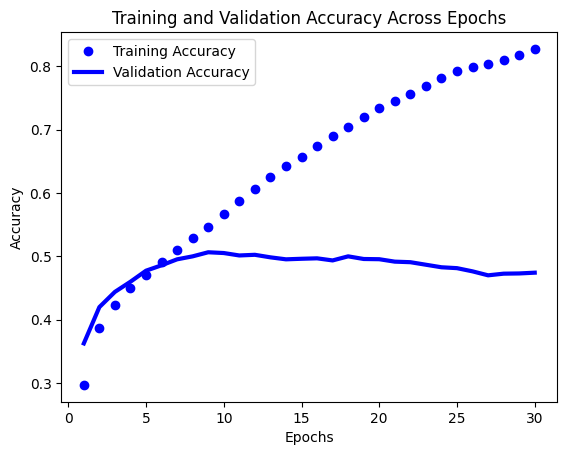

In [11]:
def plot_accuracy(model_history):
    history_dict = model_history.history
    acc = history_dict["accuracy"]
    val_acc = history_dict["val_accuracy"]
    epochs = range(1, len(acc) + 1)
    plt.plot(epochs, acc, "bo", label="Training Accuracy", linewidth=3)
    plt.plot(epochs, val_acc, "b", label="Validation Accuracy", linewidth=3)
    plt.title("Training and Validation Accuracy Across Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_accuracy(model_history)

In [12]:
test_loss, test_acc = model.evaluate(test_faces, test_emotions)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4666 - loss: 2.3073
Test Accuracy: 0.4666
Test Loss: 2.3073


# Problem 2: Wider and Deeper Models
In this problem, we will modify the model from Problem 1 in two ways:
* Increase the width of the model by adding more filters and more neurons in the dense layer.
* Increase the depth of the model by adding another dense layer.

### Part (a): Wider Model
Take the `model` from Problem 1 and modify it into `wider_model` by using 32 filters for the convolution layers instead of 16.


Write your new code below and verify that `wider_model.summary()` looks correct. Your model should have 215,527 parameters.



In [13]:
input = keras.Input(shape=train_faces.shape[1:])

x = layers.Rescaling(1./255, name="rescaling_1")(input)

x = layers.Conv2D(32, kernel_size=(2, 2), activation="relu", name="Conv_1")(x)
x = layers.MaxPooling2D(pool_size=(2, 2), name="max_pooling2d_3")(x)

x = layers.Conv2D(32, kernel_size=(2, 2), activation="relu", name="Conv_2")(x)
x = layers.MaxPooling2D(pool_size=(2, 2), name="max_pooling2d_4")(x)

x = layers.Conv2D(32, kernel_size=(2, 2), activation="relu", name="Conv_3")(x)
x = layers.MaxPooling2D(pool_size=(2, 2), name="max_pooling2d_5")(x)

x = layers.Flatten(name="flatten_1")(x)
x = layers.Dense(256, activation="relu", name="dense_1")(x)


output = layers.Dense(7, activation="softmax", name="output")(x)
wider_model = keras.Model(input, output, name='wider_cnn')
wider_model.summary()

Model: "wider_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 47, 47, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 22, 22, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 10, 10, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       205,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,527 (841.90 KB)

 Trainable params: 215,527 (841.90 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
wider_model.compile(optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

wider_model_history = wider_model.fit( x=train_faces,
    y=train_emotions,
    batch_size=64,
    epochs=30,
    validation_split=0.2
)


Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.3134 - loss: 1.7053 - val_accuracy: 0.4016 - val_loss: 1.5747
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4239 - loss: 1.5026 - val_accuracy: 0.4526 - val_loss: 1.4455
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4681 - loss: 1.3957 - val_accuracy: 0.4744 - val_loss: 1.3728
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4979 - loss: 1.3209 - val_accuracy: 0.4943 - val_loss: 1.3314
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5222 - loss: 1.2592 - val_accuracy: 0.5031 - val_loss: 1.3072
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5487 - loss: 1.1986 - val_accuracy: 0.5098 - val_loss: 1.2981
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5734 - loss: 1.1395 - val_accuracy: 0.5179 - val_loss: 1.2966
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5965 - loss: 1.0881 - val_accuracy: 0

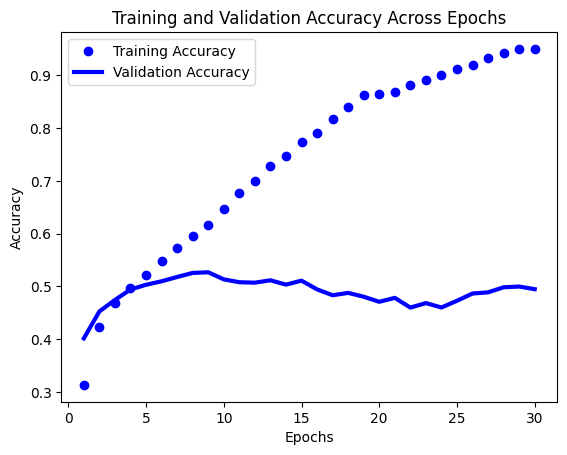

In [15]:
plot_accuracy(wider_model_history)

In [16]:
test_loss, test_acc = wider_model.evaluate(test_faces, test_emotions)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5001 - loss: 3.7384
Test Accuracy: 0.5001
Test Loss: 3.7384


## Part (d): Deeper Model
Now, build a new model called `deep_model` by taking `model` from Problem 1 and add an additional dense layer of 256 nodes immediately after the original dense layer of 256 nodes. The new model should have a total of 2 dense layers of 256 nodes each and have a total of 172,535 parameters.

Train the model, plot its accuracy vs epochs using the `plot_accuracy` function, and report the model's accuracy on the test set.

In [17]:
input = keras.Input(shape=train_faces.shape[1:], name="input")

x = layers.Rescaling(1./255, name="rescaling_1")(input)

x = layers.Conv2D(16, kernel_size=(2, 2), activation="relu", name="Conv_1")(x)
x = layers.MaxPooling2D(pool_size=(2, 2), name="max_pooling2d_3")(x)

x = layers.Conv2D(16, kernel_size=(2, 2), activation="relu", name="Conv_2")(x)
x = layers.MaxPooling2D(pool_size=(2, 2), name="max_pooling2d_4")(x)

x = layers.Conv2D(16, kernel_size=(2, 2), activation="relu", name="Conv_3")(x)
x = layers.MaxPooling2D(pool_size=(2, 2), name="max_pooling2d_5")(x)

x = layers.Flatten(name="flatten_1")(x)
x = layers.Dense(256, activation="relu", name="dense_1")(x)
x = layers.Dense(256, activation="relu", name="dense_2")(x)

output = layers.Dense(7, activation="softmax", name="output")(x)

deeper_model = keras.Model(input, output, name='deeper_model')
deeper_model.summary()

Model: "deeper_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 47, 47, 16)     │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 22, 22, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 11, 11, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 10, 10, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       102,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 172,535 (673.96 KB)

 Trainable params: 172,535 (673.96 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
deeper_model.compile(
optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

deeper_model_history = deeper_model.fit( x=train_faces,
    y=train_emotions,
    batch_size=64,
    epochs=30,
    validation_split=0.2
)


Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.2937 - loss: 1.7352 - val_accuracy: 0.3710 - val_loss: 1.6162
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3917 - loss: 1.5569 - val_accuracy: 0.4152 - val_loss: 1.5217
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4315 - loss: 1.4613 - val_accuracy: 0.4364 - val_loss: 1.4487
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4661 - loss: 1.3867 - val_accuracy: 0.4493 - val_loss: 1.4145
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4937 - loss: 1.3243 - val_accuracy: 0.4594 - val_loss: 1.3978
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5200 - loss: 1.2620 - val_accuracy: 0.4526 - val_loss: 1.4047
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5468 - loss: 1.2040 - val_accuracy: 0.4573 - val_loss: 1.4123
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5672 - loss: 1.1509 - val_accuracy: 0

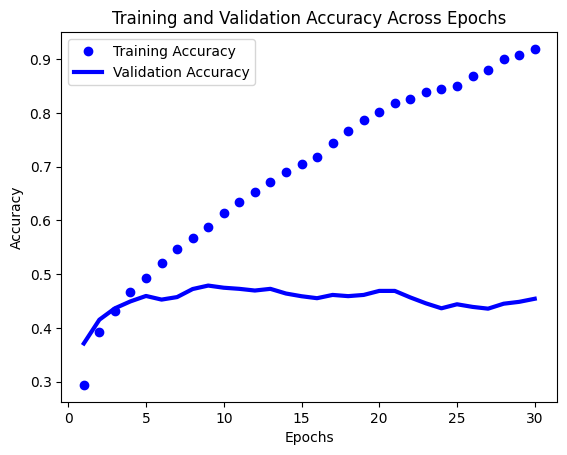

In [19]:
plot_accuracy(deeper_model_history)

In [20]:

test_loss, test_acc = deeper_model.evaluate(test_faces, test_emotions)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4465 - loss: 3.7632
Test Accuracy: 0.4465
Test Loss: 3.7632


# Problem 3: Data Augmentation

The basic idea of augmentation is to alter the image so slightly that the value of the dependent variable (i.e. the category that it belongs to) doesn't change.

Keras allows us to easily perform data augmentation using layers such as:

* `keras.layers.RandomFlip`
* `keras.layers.RandomZoom`
* `keras.layers.RandomRotation`

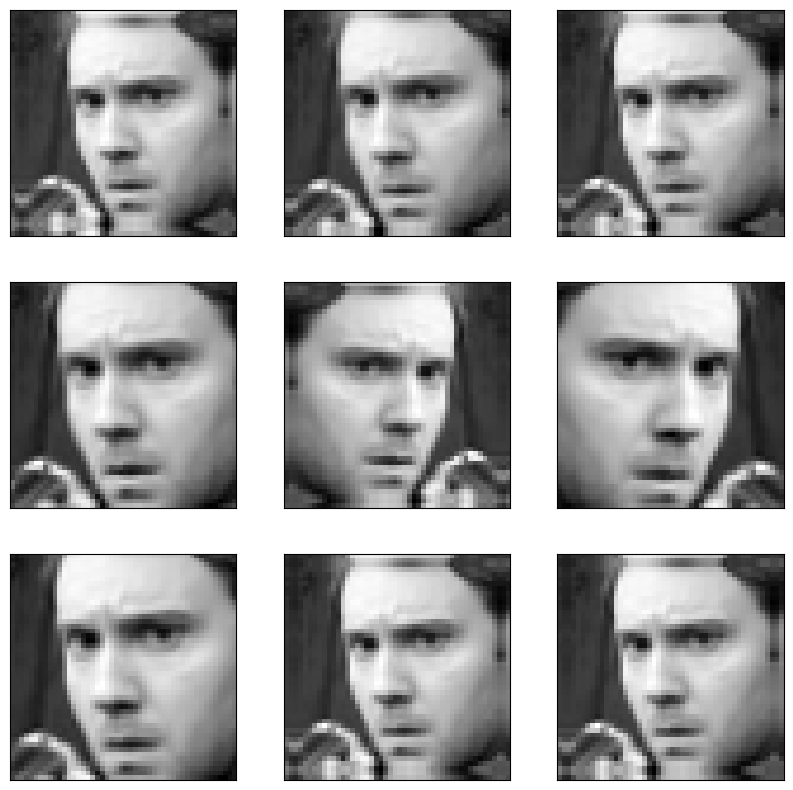

In [21]:
def augment_images(image):
    x = keras.layers.RandomFlip("horizontal")(image)
    x = keras.layers.RandomZoom(0.2)(x)
    return x

augmented_images = [augment_images(np.expand_dims(train_faces[0],axis=0)) for i in range(9)]
fig = plt.figure(figsize=(10, 10))
for i in range(9):
    ax = fig.add_subplot(3, 3, i+1, xticks=[], yticks=[])
    ax.imshow(tf.keras.preprocessing.image.array_to_img(augmented_images[i][0]), cmap='gray', vmin=0, vmax=255)

We take our model `wider_model` from Problem 2(c) and add a random flip and random zoom as **layers** before the rescaling layer.

In [22]:
input = keras.Input(shape=(48, 48, 3))

x = keras.layers.RandomFlip("horizontal")(input)
x = keras.layers.RandomZoom(0.2)(x)

x = keras.layers.Rescaling(1./255)(x)
x = keras.layers.Conv2D(32, kernel_size=(2, 2), activation="relu", name="Conv_1")(x)
x = keras.layers.Conv2D(32, kernel_size=(2, 2), activation="relu", name="Conv_2")(x)
x = keras.layers.MaxPool2D()(x)
x = keras.layers.Conv2D(32, kernel_size=(2, 2), activation="relu", name="Conv_3")(x)
x = keras.layers.MaxPool2D()(x)
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation="relu")(x)
output = keras.layers.Dense(7, activation="softmax")(x)

model_augmented = keras.Model(input, output, name='augmented_CNN_model')
model_augmented.summary()

Model: "augmented_CNN_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_9 (RandomFlip)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_9 (RandomZoom)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 47, 47, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 46, 46, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 22, 22, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3872)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       991,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,001,959 (3.82 MB)

 Trainable params: 1,001,959 (3.82 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model_augmented.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

model_augmented_history = model_augmented.fit(train_faces, train_emotions,
          batch_size=64,
          epochs=30,
          validation_split=0.2)


Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.3303 - loss: 1.6880 - val_accuracy: 0.4124 - val_loss: 1.5233
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4193 - loss: 1.5037 - val_accuracy: 0.4633 - val_loss: 1.3987
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4549 - loss: 1.4155 - val_accuracy: 0.4850 - val_loss: 1.3434
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.4803 - loss: 1.3496 - val_accuracy: 0.5064 - val_loss: 1.2888
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5082 - loss: 1.2985 - val_accuracy: 0.5226 - val_loss: 1.2615
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5201 - loss: 1.2524 - val_accuracy: 0.5301 - val_loss: 1.2343
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5420 - loss: 1.2116 - val_accuracy: 0.5350 - val_loss: 1.2075
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5583 - loss: 1.1705 - val_accu

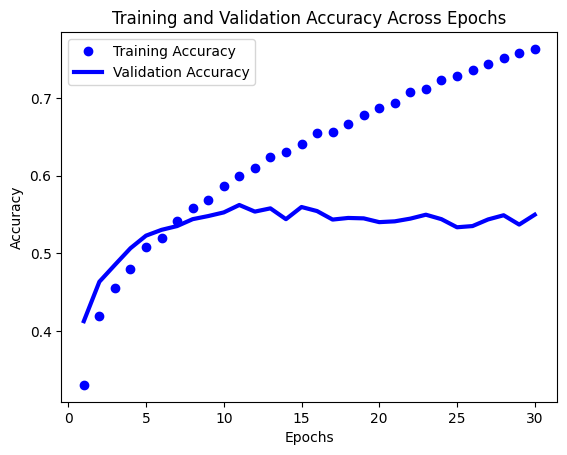

In [24]:
plot_accuracy(model_augmented_history)

In [25]:

deeper_model.evaluate(test_faces, test_emotions)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4465 - loss: 3.7632


[3.76316499710083, 0.4465031921863556]

# Problem 4: Transfer Learning and Fine-Tuning

Next, we apply transfer learning to our problem using VGG19, a pre-trained model similar to ResNet50 from class. We will take VGG19 and make it "headless", then run it through our own "little" NN.

We will take three different approaches to this:

1. Part (a): **Base Transfer Learning**. Fix the weights from headless VGG19 and learn the weights on the little NN.
2. Part (b): **Some fine-tuning** Fix the weights on the top 6 out of 19 layers of VGG19, but allow the weights from the remaining 13 layers to be optimized by SGD/Adam, in addition to those of the little NN.
3. Part (c): **Fine-Tuning** Allow all weights in VGG19 to be tuned, in addition to the little NN.

For each of the models, we will plot their train/validation accuracy curve, compute their test accuracy, and compute a confusion matrix.

# ** Part (a): No Fine Tuning**

Let us fetch the VGG19 model, making sure to set `include_top=False` so that we do not take its output layer. We also set `trainable=False` to indicate that the parameters in these 19 layers are not trainable.



In [26]:
base_model = keras.applications.VGG19(
    include_top=False,
    weights="imagenet",
    input_tensor=None,
    input_shape=(48, 48, 3),
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
)


base_model.trainable = False

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


We build a neural network that performs data augmentation and rescaling, then uses the VGG19, and finally has one dense layer before the output layer.

In [27]:
inputs = keras.Input(shape=(48, 48, 3))

x = keras.layers.RandomFlip("horizontal")(inputs)
x = keras.layers.RandomZoom(0.2)(x)
x = keras.layers.Rescaling(1./255)(x)

x = base_model(x, training=False)

x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(7, activation='softmax')(x)

transfer_model = keras.Model(inputs, outputs, name='vgg19_transfer_model')
transfer_model.summary()

Model: "vgg19_transfer_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_10 (RandomFlip)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_10 (RandomZoom)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 1, 1, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,157,511 (76.89 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [28]:
transfer_model.compile(loss='categorical_crossentropy',
            optimizer=keras.optimizers.Adam(2e-5),
            metrics=['accuracy'])

transfer_model_history = transfer_model.fit(train_faces, train_emotions, epochs=30, validation_split=0.2)

Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.1769 - loss: 2.0917 - val_accuracy: 0.2611 - val_loss: 1.7757
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.2259 - loss: 1.8852 - val_accuracy: 0.3056 - val_loss: 1.7273
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.2550 - loss: 1.8093 - val_accuracy: 0.3192 - val_loss: 1.7040
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.2744 - loss: 1.7748 - val_accuracy: 0.3260 - val_loss: 1.6893
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.2885 - loss: 1.7520 - val_accuracy: 0.3307 - val_loss: 1.6786
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.2966 - loss: 1.7369 - val_accuracy: 0.3339 - val_loss: 1.6694
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.3014 - loss: 1.7293 - val_accuracy: 0.3351 - val_loss: 1.6632
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.3066 - loss: 1.7191 - 

We can plot the training and validation accuracy curve.

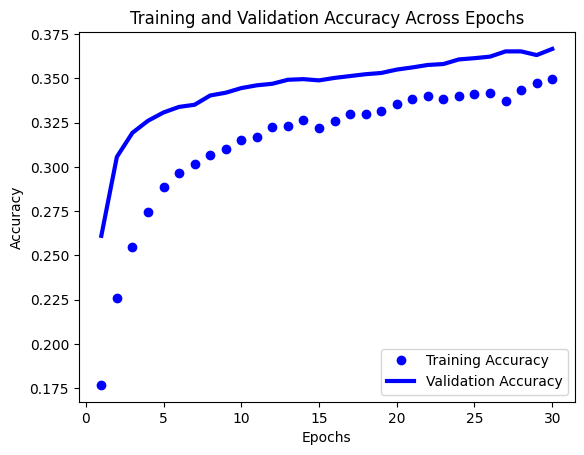

In [29]:
plot_accuracy(transfer_model_history)

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step
*************************
* Test Accuracy: 0.3604 *
*************************


,angry,disgust,fear,happy,sad,surprise,neutral
angry,76,0,35,539,107,77,124
disgust,4,0,5,64,16,9,13
fear,31,0,109,480,138,150,116
happy,34,0,46,1405,117,54,118
sad,56,0,69,638,291,42,151
surprise,21,0,52,233,26,418,81
neutral,35,0,51,676,113,70,288


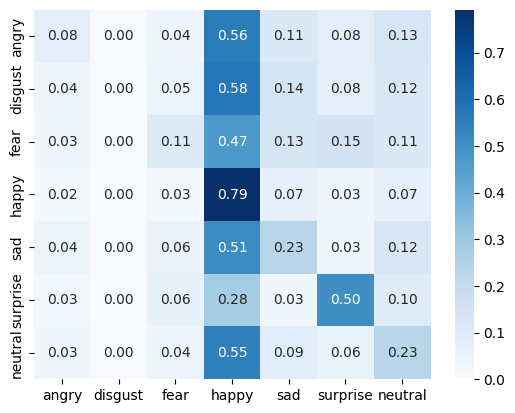

In [30]:
from IPython.display import display

def show_confusion_matrix(model):
    """
    Calculates the test accuracy, confusion matrix and heat map for a model.
    """
    global test_faces, test_emotions, emotions_names

    y_pred = model.predict(test_faces).argmax(axis=1)
    y_actual = test_emotions.argmax(axis=1)

    print('*************************\n* Test Accuracy: %.4f *\n*************************' % metrics.accuracy_score(y_actual, y_pred))

    cm = pd.DataFrame(metrics.confusion_matrix(y_actual, y_pred), index=emotions_names, columns=emotions_names)
    display(cm)

    cm = cm.div(cm.sum(axis=1), axis=0)

    sns.heatmap(cm, cmap="Blues", annot=True, fmt=".2f")

show_confusion_matrix(transfer_model)

## Part (b): Some Fine Tuning
In this part, we will allow our optimization model to tune **some** of the layers from VGG19. In particular, we will only freeze the first 15 layers and allow the remaining layers to be trained.


In [31]:
base_model = keras.applications.VGG19(
    include_top=False,
    weights="imagenet",
    input_shape=(48, 48, 3)
)

inputs = keras.Input(shape=(48, 48, 3))
x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomZoom(0.2)(x)
x = layers.Rescaling(1./255)(x)


for layer in base_model.layers[1:]:
    x = layer(x)

x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
outputs = layers.Dense(7, activation='softmax')(x)


partial_model = keras.Model(inputs, outputs, name='partial_fine_tune_model')

for layer in partial_model.layers[:15]:
    layer.trainable = False

partial_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

partial_model.summary()

Model: "partial_fine_tune_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_11 (RandomFlip)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_11 (RandomZoom)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             

 Total params: 20,157,511 (76.89 MB)

 Trainable params: 17,831,943 (68.02 MB)

 Non-trainable params: 2,325,568 (8.87 MB)

Let's see which layers are trainable. Notice that VGG19 consists of 4 blocks of convolution filters (block1_conv1, block1_conv2, ..., block5_conv4). We are allowing block4 and block5 to be trained and freezing blocks 1, 2 and 3.

In [32]:
for i, layer in enumerate(partial_model.layers):
    print('Layer %d: %s (%s), Trainable=%s' % (i+1, layer.name, layer.__class__.__name__, layer.trainable))

Layer 1: input_layer_5 (InputLayer), Trainable=False
Layer 2: random_flip_11 (RandomFlip), Trainable=False
Layer 3: random_zoom_11 (RandomZoom), Trainable=False
Layer 4: rescaling_2 (Rescaling), Trainable=False
Layer 5: block1_conv1 (Conv2D), Trainable=False
Layer 6: block1_conv2 (Conv2D), Trainable=False
Layer 7: block1_pool (MaxPooling2D), Trainable=False
Layer 8: block2_conv1 (Conv2D), Trainable=False
Layer 9: block2_conv2 (Conv2D), Trainable=False
Layer 10: block2_pool (MaxPooling2D), Trainable=False
Layer 11: block3_conv1 (Conv2D), Trainable=False
Layer 12: block3_conv2 (Conv2D), Trainable=False
Layer 13: block3_conv3 (Conv2D), Trainable=False
Layer 14: block3_conv4 (Conv2D), Trainable=False
Layer 15: block3_pool (MaxPooling2D), Trainable=False
Layer 16: block4_conv1 (Conv2D), Trainable=True
Layer 17: block4_conv2 (Conv2D), Trainable=True
Layer 18: block4_conv3 (Conv2D), Trainable=True
Layer 19: block4_conv4 (Conv2D), Trainable=True
Layer 20: block4_pool (MaxPooling2D), Trainable=

Train the model and examine its train/validation curve, test accuracy and confusion matrix.

In [33]:
partial_model.compile(loss='categorical_crossentropy',
            optimizer=keras.optimizers.Adam(2e-5),
            metrics=['accuracy'])

partial_model_history = partial_model.fit(train_faces, train_emotions, epochs=30, validation_split=0.2)

Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.4158 - loss: 1.5015 - val_accuracy: 0.4807 - val_loss: 1.3671
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 39s 53ms/step - accuracy: 0.5080 - loss: 1.2946 - val_accuracy: 0.5075 - val_loss: 1.2809
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 38s 53ms/step - accuracy: 0.5404 - loss: 1.2051 - val_accuracy: 0.5333 - val_loss: 1.2221
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 38s 53ms/step - accuracy: 0.5730 - loss: 1.1322 - val_accuracy: 0.5413 - val_loss: 1.2054
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 38s 53ms/step - accuracy: 0.6013 - loss: 1.0660 - val_accuracy: 0.5482 - val_loss: 1.1999
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 38s 53ms/step - accuracy: 0.6269 - loss: 1.0066 - val_accuracy: 0.5665 - val_loss: 1.1629
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 38s 53ms/step - accuracy: 0.6509 - loss: 0.9441 - val_accuracy: 0.5571 - val_loss: 1.1990
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 38s 53ms/step - accuracy: 0.6737 - loss: 0.8849 - 

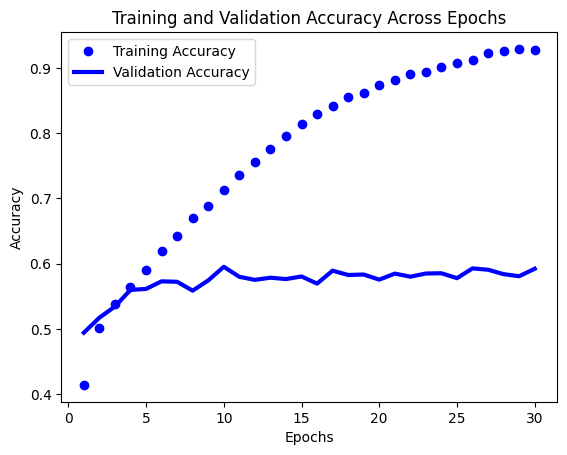

In [ ]:
plot_accuracy(partial_model_history)

225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step
*************************
* Test Accuracy: 0.5816 *
*************************


,angry,disgust,fear,happy,sad,surprise,neutral
angry,430,2,83,95,243,26,79
disgust,31,40,7,6,22,2,3
fear,132,3,372,53,305,86,73
happy,42,0,36,1420,160,38,78
sad,113,4,93,97,770,19,151
surprise,33,0,77,43,54,601,23
neutral,69,1,69,150,367,35,542


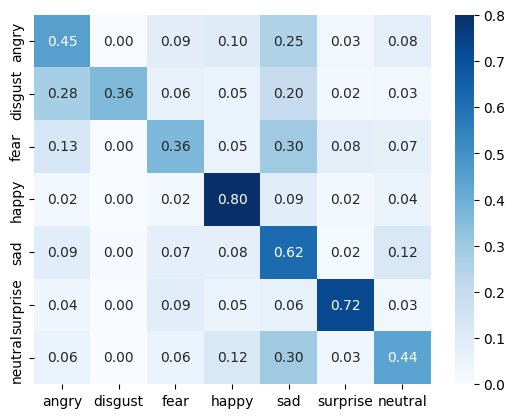

In [ ]:
show_confusion_matrix(partial_model)

## Part (c): Fine Tuning
Now, let's try a transfer learning model where all layers can be fine tuned.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

base_model = keras.applications.VGG19(
    include_top=False,
    weights="imagenet",
    input_shape=(48, 48, 3)
)

inputs = keras.Input(shape=(48, 48, 3))
x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomZoom(0.2)(x)
x = layers.Rescaling(1./255)(x)
for layer in base_model.layers[1:]:
    x = layer(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
outputs = layers.Dense(7, activation='softmax')(x)

tuned_model = keras.Model(inputs, outputs, name='full_fine_tune_model')

for i, layer in enumerate(tuned_model.layers):
    print(f'Layer {i+1}: {layer.name} ({layer.__class__.__name__}), Trainable={layer.trainable}')

Layer 1: input_layer_18 (InputLayer), Trainable=True
Layer 2: random_flip_19 (RandomFlip), Trainable=True
Layer 3: random_zoom_19 (RandomZoom), Trainable=True
Layer 4: rescaling_9 (Rescaling), Trainable=True
Layer 5: block1_conv1 (Conv2D), Trainable=True
Layer 6: block1_conv2 (Conv2D), Trainable=True
Layer 7: block1_pool (MaxPooling2D), Trainable=True
Layer 8: block2_conv1 (Conv2D), Trainable=True
Layer 9: block2_conv2 (Conv2D), Trainable=True
Layer 10: block2_pool (MaxPooling2D), Trainable=True
Layer 11: block3_conv1 (Conv2D), Trainable=True
Layer 12: block3_conv2 (Conv2D), Trainable=True
Layer 13: block3_conv3 (Conv2D), Trainable=True
Layer 14: block3_conv4 (Conv2D), Trainable=True
Layer 15: block3_pool (MaxPooling2D), Trainable=True
Layer 16: block4_conv1 (Conv2D), Trainable=True
Layer 17: block4_conv2 (Conv2D), Trainable=True
Layer 18: block4_conv3 (Conv2D), Trainable=True
Layer 19: block4_conv4 (Conv2D), Trainable=True
Layer 20: block4_pool (MaxPooling2D), Trainable=True
Layer 21:

In [ ]:
tuned_model.compile(loss='categorical_crossentropy',
            optimizer=keras.optimizers.Adam(2e-5),
            metrics=['accuracy'])

tuned_model_history = tuned_model.fit(train_faces, train_emotions, epochs=30, validation_split=0.2)

Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 51s 65ms/step - accuracy: 0.3665 - loss: 1.5964 - val_accuracy: 0.5200 - val_loss: 1.2582
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.5298 - loss: 1.2328 - val_accuracy: 0.5648 - val_loss: 1.1434
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.5626 - loss: 1.1432 - val_accuracy: 0.5578 - val_loss: 1.1651
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.5940 - loss: 1.0774 - val_accuracy: 0.5730 - val_loss: 1.1343
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.6155 - loss: 1.0134 - val_accuracy: 0.5871 - val_loss: 1.1024
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 48s 67ms/step - accuracy: 0.6418 - loss: 0.9449 - val_accuracy: 0.5911 - val_loss: 1.0992
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 82s 68ms/step - accuracy: 0.6661 - loss: 0.8922 - val_accuracy: 0.6062 - val_loss: 1.0598
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 82s 68ms/step - accuracy: 0.6914 - loss: 0.8366 - 

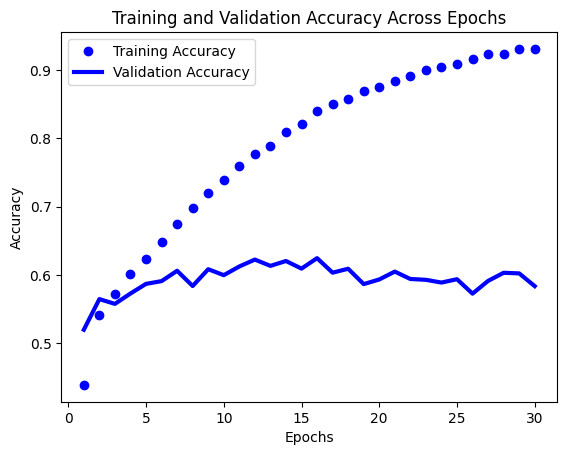

In [ ]:
plot_accuracy(tuned_model_history)

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step
*************************
* Test Accuracy: 0.5797 *
*************************


,angry,disgust,fear,happy,sad,surprise,neutral
angry,499,2,95,43,264,35,20
disgust,34,42,7,2,20,3,3
fear,103,3,367,34,367,110,40
happy,48,3,20,1405,184,67,47
sad,151,6,78,45,877,25,65
surprise,26,0,59,29,63,646,8
neutral,118,2,40,116,584,48,325


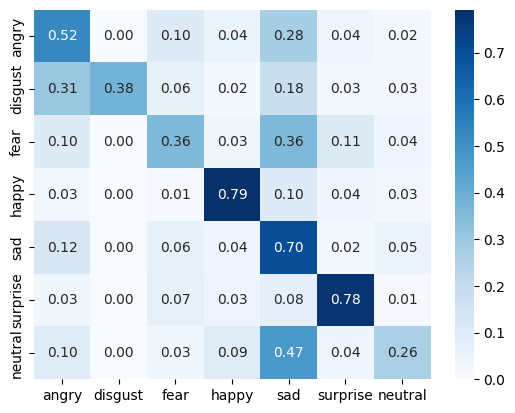

In [ ]:
show_confusion_matrix(tuned_model)